# Lecture 28: Classification of Symplectic Toric Manifolds

**Source span.** Printed pages 175-180; physical PDF pages 189-194 in `Lectures on Symplectic Geometry.pdf`. The extraction also checked the beginning of Lecture 29 to confirm the chapter boundary.

**Chapter goal.** This lecture states the Delzant classification of compact symplectic toric manifolds and starts the construction that realizes a Delzant polytope as a toric manifold. The key shift is from analysis on a symplectic manifold to combinatorics of a labeled polytope: simple, rational, smooth polytopes encode the possible moment images.

The notebook turns every source ingredient into an inspectable object: Delzant vertex tests, primitive outward normal checks, half-space descriptions, the theorem route from toric data to a moment image, the exact sequence behind the construction, and the interval example whose reduction is `CP^1`. No textbook diagrams or prose are copied; the figures are generated from small coordinate models.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import networkx as nx
import numpy as np
import sympy as sp
from IPython.display import Image, display


def find_book_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "artifacts").is_dir():
            return candidate
    raise RuntimeError("Could not locate LSG course root.")


BOOK_ROOT = find_book_root()
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "lecture-28"
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
for folder in (FIGURES, CHECKS):
    folder.mkdir(parents=True, exist_ok=True)


def rel(path: Path) -> str:
    return path.relative_to(BOOK_ROOT).as_posix()


def write_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def display_artifact(relative_path: str, *, width: int = 760) -> None:
    display(Image(filename=str(BOOK_ROOT / relative_path), width=width))


source_span = {
    "lecture": 28,
    "title": "Classification of Symplectic Toric Manifolds",
    "printed_pages": "175-180",
    "physical_pdf_pages": "189-194",
    "source_note": (
        "Read the local PDF section on Delzant polytopes, primitive normals, "
        "Delzant theorem, the construction sketch from facets and exact sequences, "
        "and the interval example reducing to CP^1."
    ),
}
write_json(CHECKS / "source-span.json", source_span)
source_span

{'lecture': 28,
 'title': 'Classification of Symplectic Toric Manifolds',
 'printed_pages': '175-180',
 'physical_pdf_pages': '189-194',
 'source_note': 'Read the local PDF section on Delzant polytopes, primitive normals, Delzant theorem, the construction sketch from facets and exact sequences, and the interval example reducing to CP^1.'}

## Translation Guide

`Symplectic toric manifold` means a compact connected `2n`-dimensional symplectic manifold with an effective Hamiltonian action of the `n`-torus and a moment map. The moment map image is the polytope that classifies the Hamiltonian space.

`Delzant polytope` means simple, rational, and smooth. In coordinates, a vertex in an `n`-polytope has `n` edge directions; rationality says those edge directions can be lattice directions; smoothness says the primitive directions form a `Z^n` basis. In two dimensions, smoothness can be checked by adjacent primitive normal determinants having absolute value one.

`Primitive outward normal` means a lattice normal vector to a facet with no common integer factor. The source writes a polytope as an intersection of half-spaces `<x,v_i> <= lambda_i`, using these primitive outward normals.

`Delzant theorem` says the assignment from a toric manifold to its moment image gives a one-to-one classification by Delzant polytopes. The construction side starts with a polytope with `d` facets, maps `R^d -> R^n` by sending standard basis vectors to the normals, restricts the standard torus action on `C^d` to the kernel subtorus, and then reduces the zero level.

## Library Routing

Matplotlib is used for the polygon, normal, and interval-reduction figures because the source geometry is low-dimensional and label-sensitive. NetworkX is used for the theorem/construction route and the exact-sequence dependency diagram because the proof sketch is a pipeline. NumPy and SymPy perform the lattice, determinant, rank, kernel, and zero-level checks so the Delzant conditions are audited rather than only described.

In [2]:
storyboard = {
    "chapter_goal": "Classify toric manifolds by Delzant polytopes and make the construction sketch executable.",
    "source_span_read": source_span,
    "library_routing": [
        {
            "concept": "Delzant polytope tests",
            "representation": "polygon panels with primitive normals and determinant checks",
            "library": "Matplotlib + NumPy",
            "why": "simplicity, rationality, and smoothness are visible at facets and vertices",
            "fallback": "determinant table",
        },
        {
            "concept": "half-space normal description",
            "representation": "standard simplex with inequalities and outward normals",
            "library": "Matplotlib",
            "why": "the construction uses normals and lambda constants, not only vertices",
            "fallback": "inequality ledger",
        },
        {
            "concept": "Delzant theorem route",
            "representation": "proof/construction dependency graph",
            "library": "NetworkX",
            "why": "classification and construction are a chain of data transformations",
            "fallback": "ordered checklist",
        },
        {
            "concept": "exact sequence and subtorus N",
            "representation": "matrix rank/kernel diagram",
            "library": "SymPy + Matplotlib",
            "why": "pi: R^d -> R^n and its kernel are algebraic gates in the construction",
            "fallback": "rank table",
        },
        {
            "concept": "interval example reduces to CP^1",
            "representation": "zero-level radius and diagonal S^1 quotient",
            "library": "Matplotlib + NumPy",
            "why": "the simplest Delzant construction is concrete enough for numerical checks",
            "fallback": "equation table",
        },
    ],
    "visual_sequence": [
        {
            "concept": "Delzant polygon and failure tests",
            "artifact": rel(FIGURES / "delzant-polygon-normal-checks.png"),
            "inspection_target": "read which vertices pass primitive determinant tests and which fail smoothness",
            "validation": "standard simplex determinant defects vanish; bad triangle defect is nonzero",
        },
        {
            "concept": "Half-space description by primitive outward normals",
            "artifact": rel(FIGURES / "simplex-halfspace-primitive-normals.png"),
            "inspection_target": "match each facet inequality with its primitive outward normal",
            "validation": "all normals are primitive and active pairs define vertices",
        },
        {
            "concept": "Delzant theorem and construction route",
            "artifact": rel(FIGURES / "delzant-classification-proof-route.png"),
            "inspection_target": "trace toric data to moment image and Delzant polytope to reduction",
            "validation": "route graph has the expected path from polytope to toric manifold",
        },
        {
            "concept": "Exact sequence from facets",
            "artifact": rel(FIGURES / "delzant-construction-exact-sequence.png"),
            "inspection_target": "see how d facet normals produce pi, N, and the dual projection",
            "validation": "rank(pi)=n and kernel dimension d-n",
        },
        {
            "concept": "Interval polytope gives CP^1",
            "artifact": rel(FIGURES / "interval-polytope-cp1-reduction.png"),
            "inspection_target": "connect Delta=[0,a], diagonal subgroup, zero sphere, and projective quotient",
            "validation": "zero-level samples satisfy |z1|^2+|z2|^2=2a",
        },
    ],
}
write_json(CHECKS / "visual-storyboard.json", storyboard)
print("planned visuals:", len(storyboard["visual_sequence"]))

planned visuals: 5


## Delzant Polytopes

The source definition has three independent tests. Simple controls how many edges meet at a vertex, rational controls whether the edge directions are lattice directions, and smooth controls whether the primitive lattice directions form a basis. For two-dimensional polygons, the smooth vertex test is the determinant test: adjacent primitive outward normals must have determinant `+/-1`.

The left panel checks the standard simplex with normals `(-1,0)`, `(0,-1)`, `(1,1)`. Every adjacent determinant has absolute value one. The right panel changes one slanted normal to `(1,2)`, which keeps a rational polygon but fails the smoothness test at one vertex.

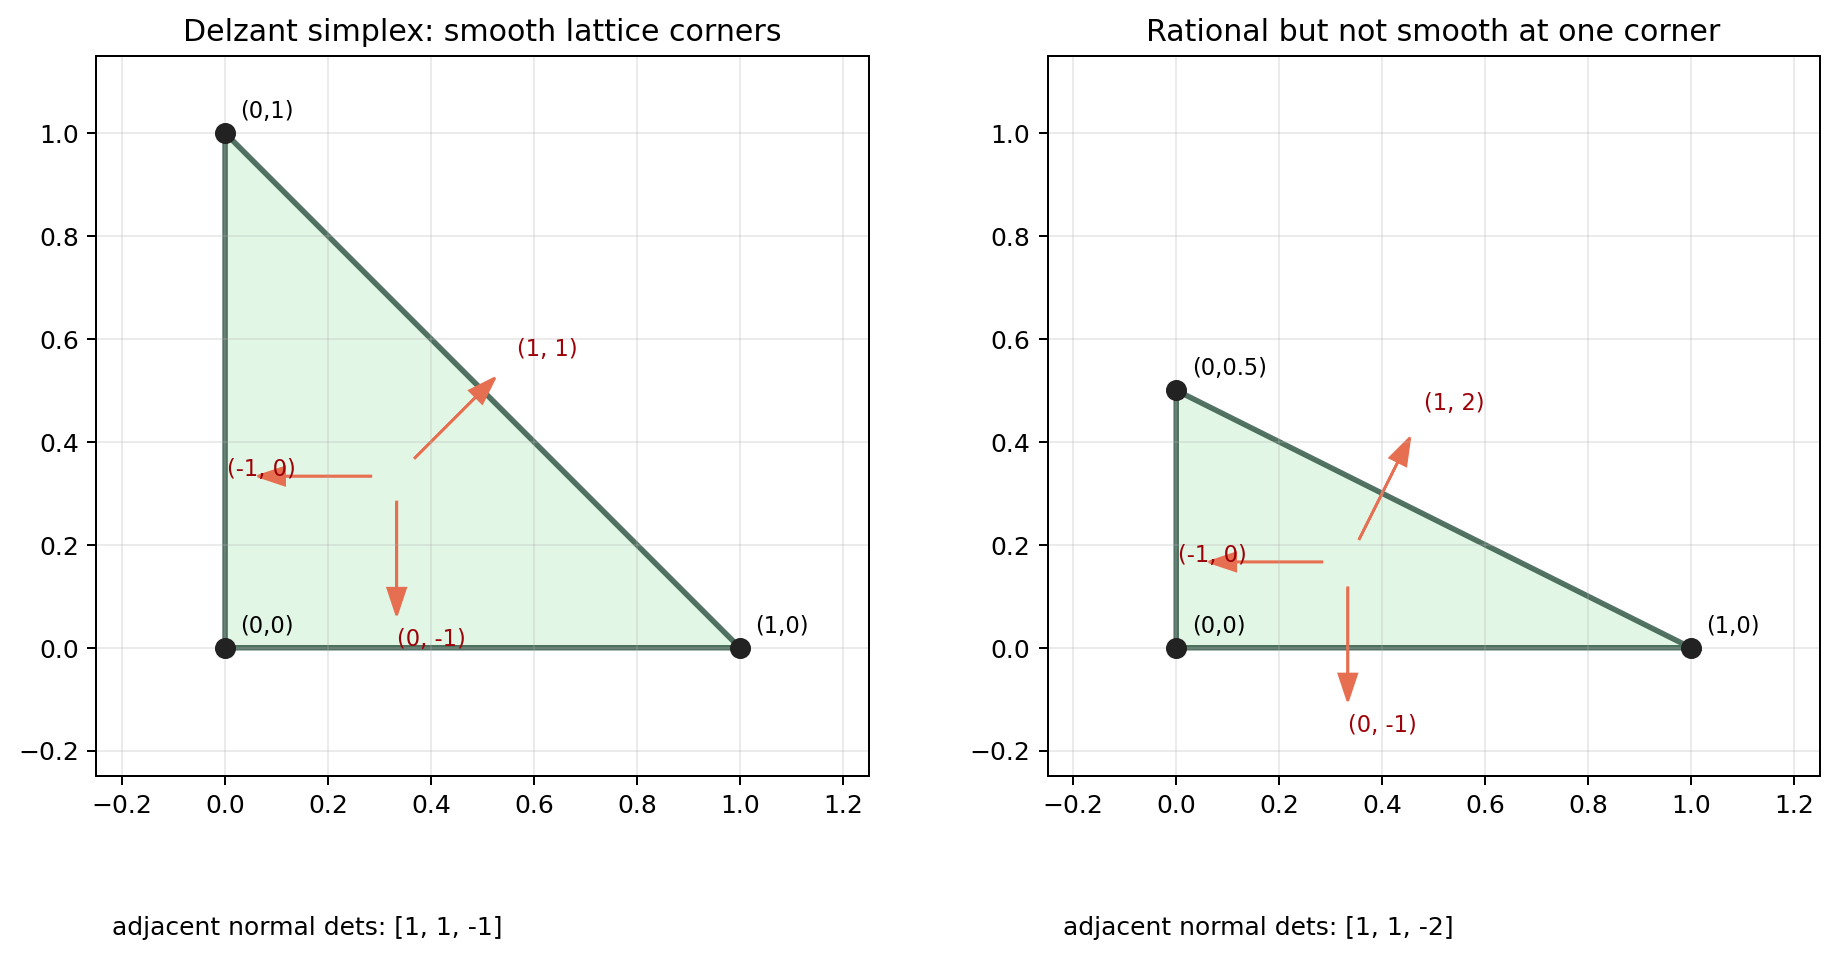

In [3]:
def primitive(v):
    v = np.array(v, dtype=int)
    gcd = math.gcd(abs(int(v[0])), abs(int(v[1])))
    return tuple((v // gcd).tolist()) if gcd else tuple(v.tolist())


def det2(a, b):
    return int(round(np.linalg.det(np.array([a, b], dtype=float))))


standard_vertices = np.array([[0, 0], [1, 0], [0, 1]])
standard_normals = [(-1, 0), (0, -1), (1, 1)]
standard_active = {
    (0, 0): [(-1, 0), (0, -1)],
    (1, 0): [(0, -1), (1, 1)],
    (0, 1): [(-1, 0), (1, 1)],
}
standard_dets = [det2(*pair) for pair in standard_active.values()]

bad_vertices = np.array([[0, 0], [1, 0], [0, 0.5]])
bad_normals = [(-1, 0), (0, -1), (1, 2)]
bad_active = {
    (0, 0): [(-1, 0), (0, -1)],
    (1, 0): [(0, -1), (1, 2)],
    (0, 0.5): [(-1, 0), (1, 2)],
}
bad_dets = [det2(*pair) for pair in bad_active.values()]
standard_defect = max(abs(abs(det) - 1) for det in standard_dets)
bad_smooth_defect = max(abs(abs(det) - 1) for det in bad_dets)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
for ax, vertices, normals, title, dets in [
    (axes[0], standard_vertices, standard_normals, "Delzant simplex: smooth lattice corners", standard_dets),
    (axes[1], bad_vertices, bad_normals, "Rational but not smooth at one corner", bad_dets),
]:
    ax.add_patch(Polygon(vertices, closed=True, facecolor="#d8f3dc", edgecolor="#1b4332", linewidth=2.2, alpha=0.75))
    center = vertices.mean(axis=0)
    for vertex in vertices:
        ax.scatter(*vertex, color="#222222", s=55, zorder=3)
        ax.annotate(f"({vertex[0]:g},{vertex[1]:g})", vertex + np.array([0.03, 0.03]), fontsize=9)
    for normal in normals:
        n = np.array(normal, dtype=float)
        n = n / np.linalg.norm(n)
        start = center + 0.05 * n
        ax.arrow(start[0], start[1], 0.22 * n[0], 0.22 * n[1], color="#e76f51", head_width=0.035, length_includes_head=True)
        ax.text(start[0] + 0.28 * n[0], start[1] + 0.28 * n[1], str(normal), color="#9d0208", fontsize=9)
    ax.text(0.02, -0.22, f"adjacent normal dets: {dets}", transform=ax.transAxes, fontsize=10)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-0.25, 1.25)
    ax.set_ylim(-0.25, 1.15)
    ax.grid(True, alpha=0.25)

polygon_path = FIGURES / "delzant-polygon-normal-checks.png"
fig.savefig(polygon_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert standard_defect == 0
assert bad_smooth_defect > 0
display_artifact(rel(polygon_path))

## Half-Spaces And Primitive Outward Normals

The construction does not start from a picture of a polygon. It starts from a list of primitive outward normals and constants:

`Delta = {x | <x,v_i> <= lambda_i}`.

For the standard simplex, the inequalities are `x1 >= 0`, `x2 >= 0`, and `x1+x2 <= 1`, or equivalently `<x,(-1,0)> <= 0`, `<x,(0,-1)> <= 0`, `<x,(1,1)> <= 1`. The figure labels the facets by their normals, because those are what feed the map `pi: R^d -> R^n`.

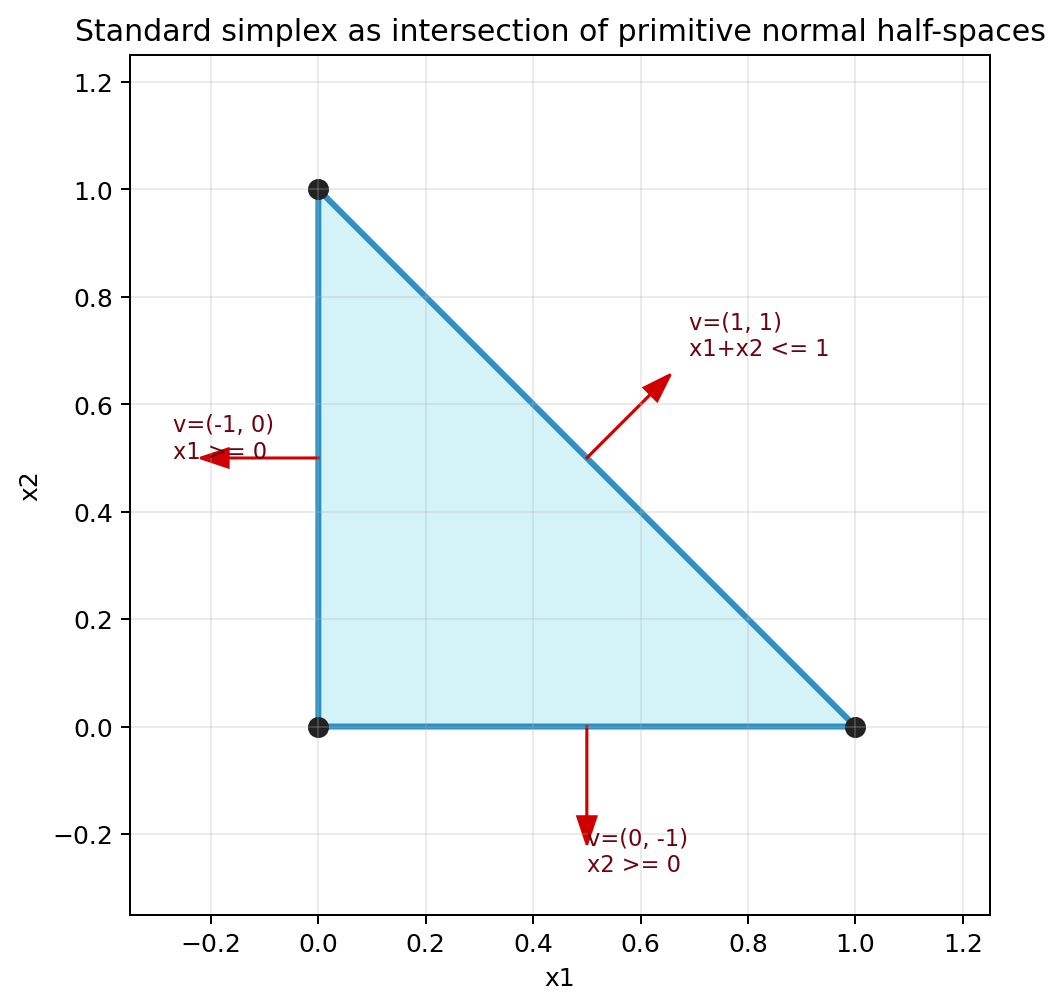

In [4]:
inequalities = [
    {"normal": (-1, 0), "lambda": 0, "label": "x1 >= 0"},
    {"normal": (0, -1), "lambda": 0, "label": "x2 >= 0"},
    {"normal": (1, 1), "lambda": 1, "label": "x1+x2 <= 1"},
]
primitive_checks = [primitive(item["normal"]) == item["normal"] for item in inequalities]
active_vertices = []
for i in range(len(inequalities)):
    for j in range(i + 1, len(inequalities)):
        A = np.array([inequalities[i]["normal"], inequalities[j]["normal"]], dtype=float)
        b = np.array([inequalities[i]["lambda"], inequalities[j]["lambda"]], dtype=float)
        x_vertex = np.linalg.solve(A, b)
        if all(np.dot(x_vertex, item["normal"]) <= item["lambda"] + 1e-10 for item in inequalities):
            active_vertices.append(tuple(np.round(x_vertex, 8)))

fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.add_patch(Polygon(standard_vertices, closed=True, facecolor="#caf0f8", edgecolor="#0077b6", linewidth=2.4, alpha=0.8))
facet_midpoints = [np.array([0, 0.5]), np.array([0.5, 0]), np.array([0.5, 0.5])]
for item, midpoint in zip(inequalities, facet_midpoints):
    n = np.array(item["normal"], dtype=float)
    n = n / np.linalg.norm(n)
    ax.arrow(midpoint[0], midpoint[1], 0.22 * n[0], 0.22 * n[1], color="#d00000", head_width=0.035, length_includes_head=True)
    ax.text(midpoint[0] + 0.27 * n[0], midpoint[1] + 0.27 * n[1], f"v={item['normal']}\n{item['label']}", fontsize=9, color="#6a040f")
for vertex in active_vertices:
    ax.scatter(*vertex, color="#222222", s=55)
ax.set_title("Standard simplex as intersection of primitive normal half-spaces")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect("equal")
ax.set_xlim(-0.35, 1.25)
ax.set_ylim(-0.35, 1.25)
ax.grid(True, alpha=0.25)
simplex_path = FIGURES / "simplex-halfspace-primitive-normals.png"
fig.savefig(simplex_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert all(primitive_checks)
assert len(active_vertices) == 3
display_artifact(rel(simplex_path))

## Delzant Theorem As A Route

The theorem says that compact symplectic toric manifolds are classified by Delzant polytopes through the moment image. The proof material in this lecture focuses on existence: given a polytope, build the toric manifold. The route graph separates the classification statement from the construction ingredients that will be proved in detail in Lecture 29.

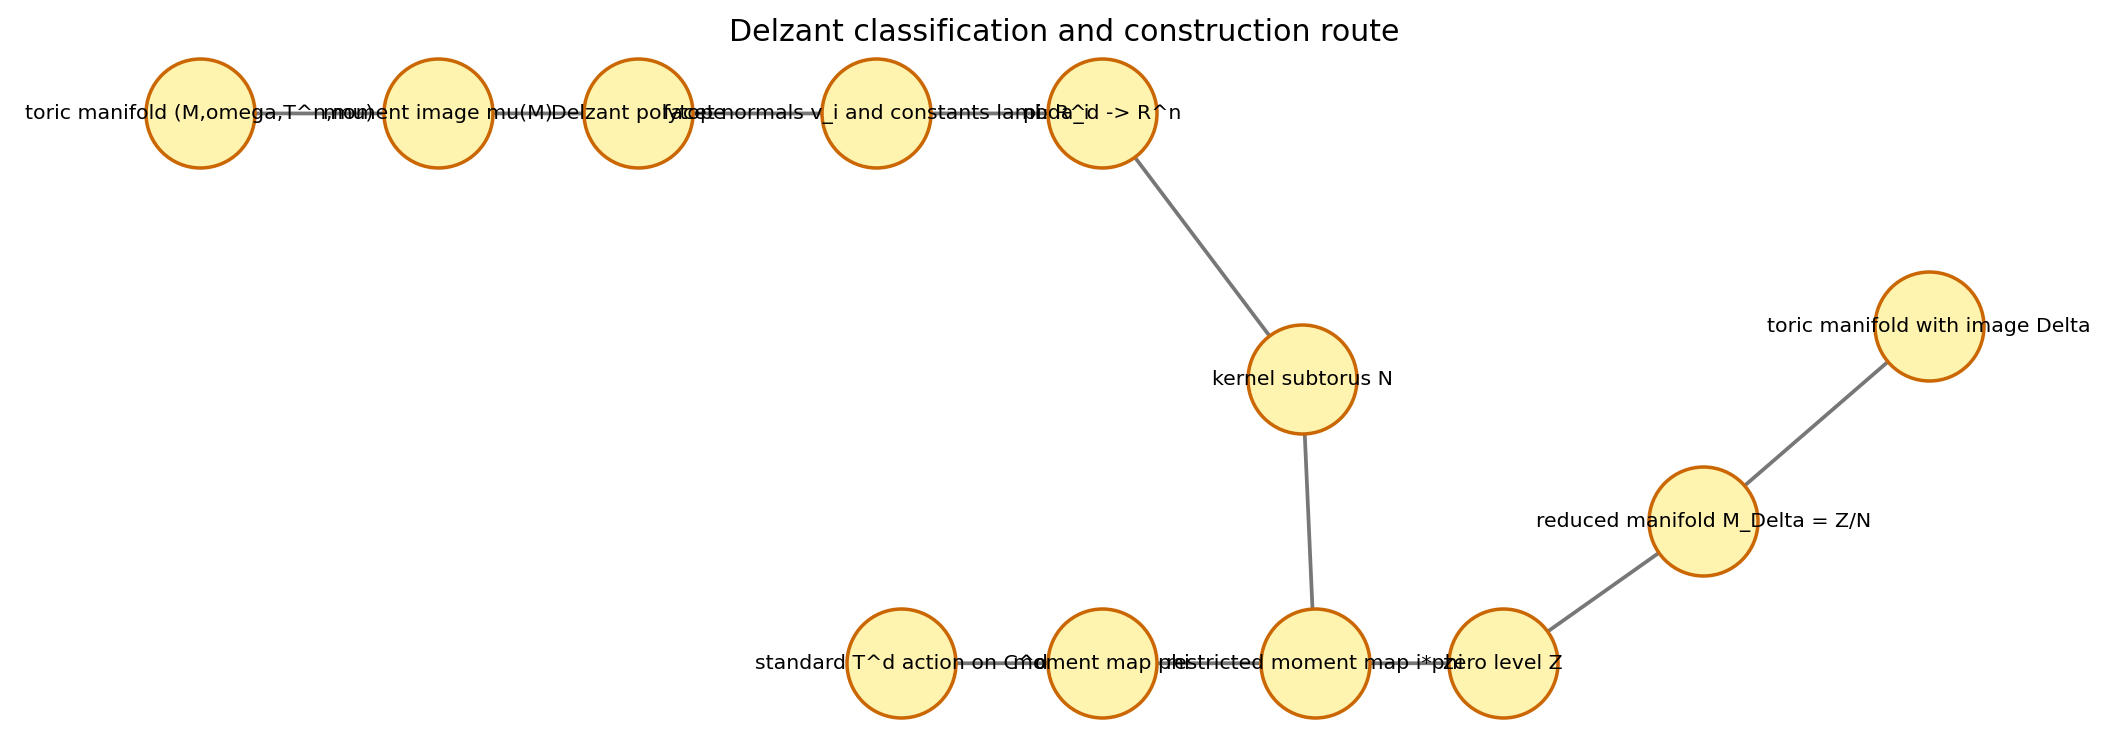

In [5]:
G = nx.DiGraph()
edges = [
    ("toric manifold (M,omega,T^n,mu)", "moment image mu(M)"),
    ("moment image mu(M)", "Delzant polytope"),
    ("Delzant polytope", "facet normals v_i and constants lambda_i"),
    ("facet normals v_i and constants lambda_i", "pi: R^d -> R^n"),
    ("pi: R^d -> R^n", "kernel subtorus N"),
    ("standard T^d action on C^d", "moment map phi"),
    ("kernel subtorus N", "restricted moment map i*phi"),
    ("moment map phi", "restricted moment map i*phi"),
    ("restricted moment map i*phi", "zero level Z"),
    ("zero level Z", "reduced manifold M_Delta = Z/N"),
    ("reduced manifold M_Delta = Z/N", "toric manifold with image Delta"),
]
G.add_edges_from(edges)
pos = {
    "toric manifold (M,omega,T^n,mu)": (0, 2),
    "moment image mu(M)": (1.9, 2),
    "Delzant polytope": (3.5, 2),
    "facet normals v_i and constants lambda_i": (5.4, 2),
    "pi: R^d -> R^n": (7.2, 2),
    "kernel subtorus N": (8.8, 1.25),
    "standard T^d action on C^d": (5.6, 0.45),
    "moment map phi": (7.2, 0.45),
    "restricted moment map i*phi": (8.9, 0.45),
    "zero level Z": (10.4, 0.45),
    "reduced manifold M_Delta = Z/N": (12.0, 0.85),
    "toric manifold with image Delta": (13.8, 1.4),
}
fig, ax = plt.subplots(figsize=(15, 4.8))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=15, width=1.5, edge_color="#777777")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#fff3b0", edgecolors="#ca6702", node_size=1900, linewidths=1.4)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8.2)
ax.set_title("Delzant classification and construction route")
ax.set_axis_off()
route_path = FIGURES / "delzant-classification-proof-route.png"
fig.savefig(route_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert nx.has_path(G, "Delzant polytope", "toric manifold with image Delta")
assert nx.is_directed_acyclic_graph(G)
display_artifact(rel(route_path))

## Exact Sequence From Facets

For a polytope with `d` facets in dimension `n`, the construction sends each standard basis vector `e_i` in `R^d` to the primitive outward normal `v_i` in `R^n`. The Delzant condition guarantees that `pi` is onto and maps the integer lattice onto the integer lattice. Its kernel is the Lie algebra of the subtorus `N`; the dual sequence supplies the projection `i*` used to restrict the `C^d` moment map.

The matrix below uses the simplex normals. Here `d=3`, `n=2`, `rank(pi)=2`, and the kernel dimension is `1`, matching the exact-sequence count.

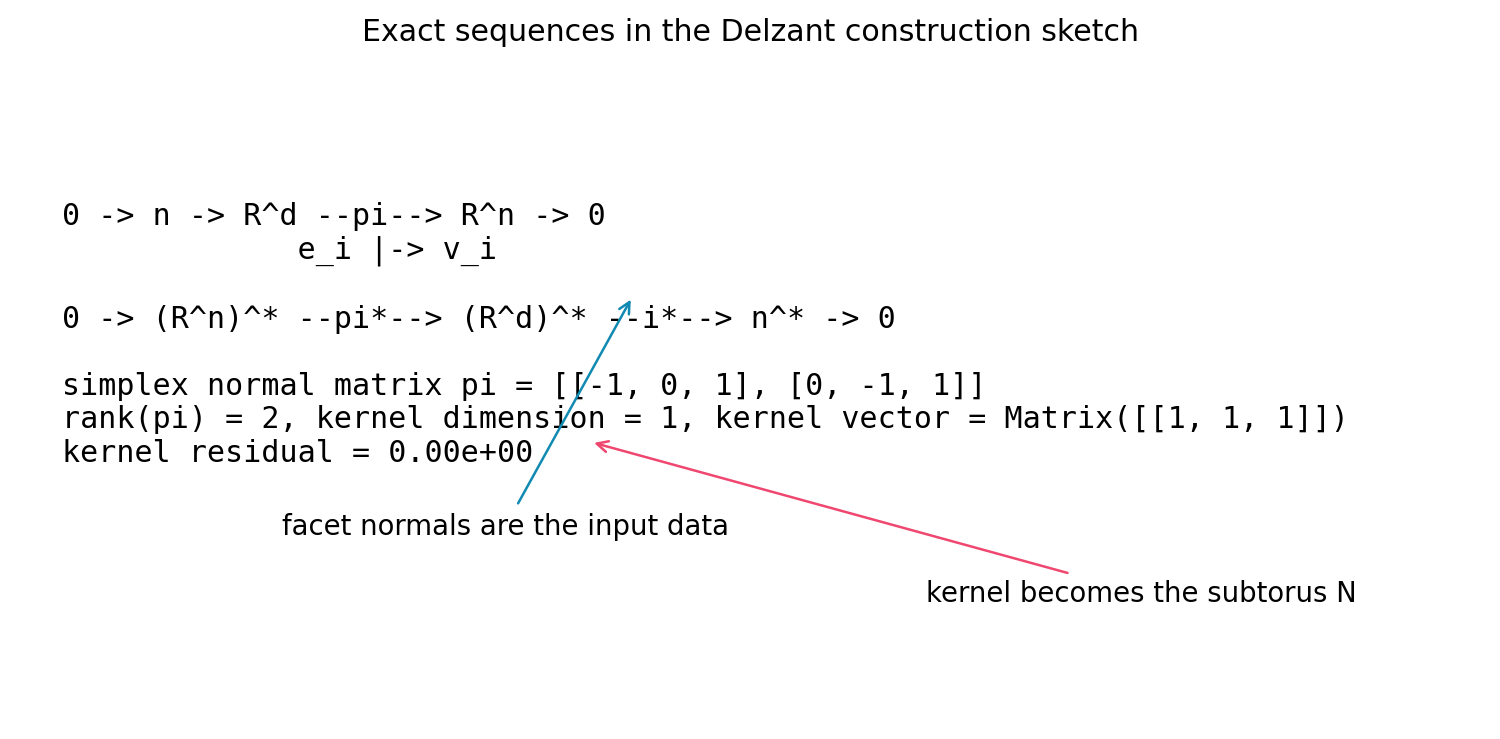

In [6]:
Pi = sp.Matrix([[-1, 0, 1], [0, -1, 1]])
rank_pi = int(Pi.rank())
kernel_basis = Pi.nullspace()
kernel_dim = len(kernel_basis)
kernel_vector = np.array(kernel_basis[0], dtype=float).reshape(-1)
kernel_residual = float(np.linalg.norm(np.array(Pi, dtype=float) @ kernel_vector))

fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.axis("off")
sequence_text = (
    "0 -> n -> R^d --pi--> R^n -> 0\n"
    "             e_i |-> v_i\n\n"
    "0 -> (R^n)^* --pi*--> (R^d)^* --i*--> n^* -> 0\n\n"
    f"simplex normal matrix pi = [[-1, 0, 1], [0, -1, 1]]\n"
    f"rank(pi) = {rank_pi}, kernel dimension = {kernel_dim}, kernel vector = {kernel_basis[0].T}\n"
    f"kernel residual = {kernel_residual:.2e}"
)
ax.text(0.03, 0.78, sequence_text, family="monospace", fontsize=12, va="top")
ax.annotate("facet normals are the input data", xy=(0.42, 0.64), xytext=(0.18, 0.28), arrowprops=dict(arrowstyle="->", color="#118ab2"), fontsize=11)
ax.annotate("kernel becomes the subtorus N", xy=(0.39, 0.42), xytext=(0.62, 0.18), arrowprops=dict(arrowstyle="->", color="#ef476f"), fontsize=11)
ax.set_title("Exact sequences in the Delzant construction sketch")
exact_path = FIGURES / "delzant-construction-exact-sequence.png"
fig.savefig(exact_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert rank_pi == 2
assert kernel_dim == 1
assert kernel_residual < 1e-12
display_artifact(rel(exact_path))

## Interval Example: Delta = [0,a] Gives CP1

The source ends the lecture with the easiest construction. For the interval, there are two normals `v1=-1` and `v2=1`, so `pi: R^2 -> R` has kernel spanned by `(1,1)`. The subtorus `N` is the diagonal circle in `T^2`. The restricted moment map is `-1/2(|z1|^2+|z2|^2)+a`; its zero level is a sphere of radius `sqrt(2a)` in `C^2`, and quotienting by the diagonal circle gives `CP^1`.

The left panel shows the interval and normals. The right panel shows the zero-level radius relation in the `(r1,r2)` quadrant, which is the quotient of the sphere by the phase variables before the final diagonal phase quotient.

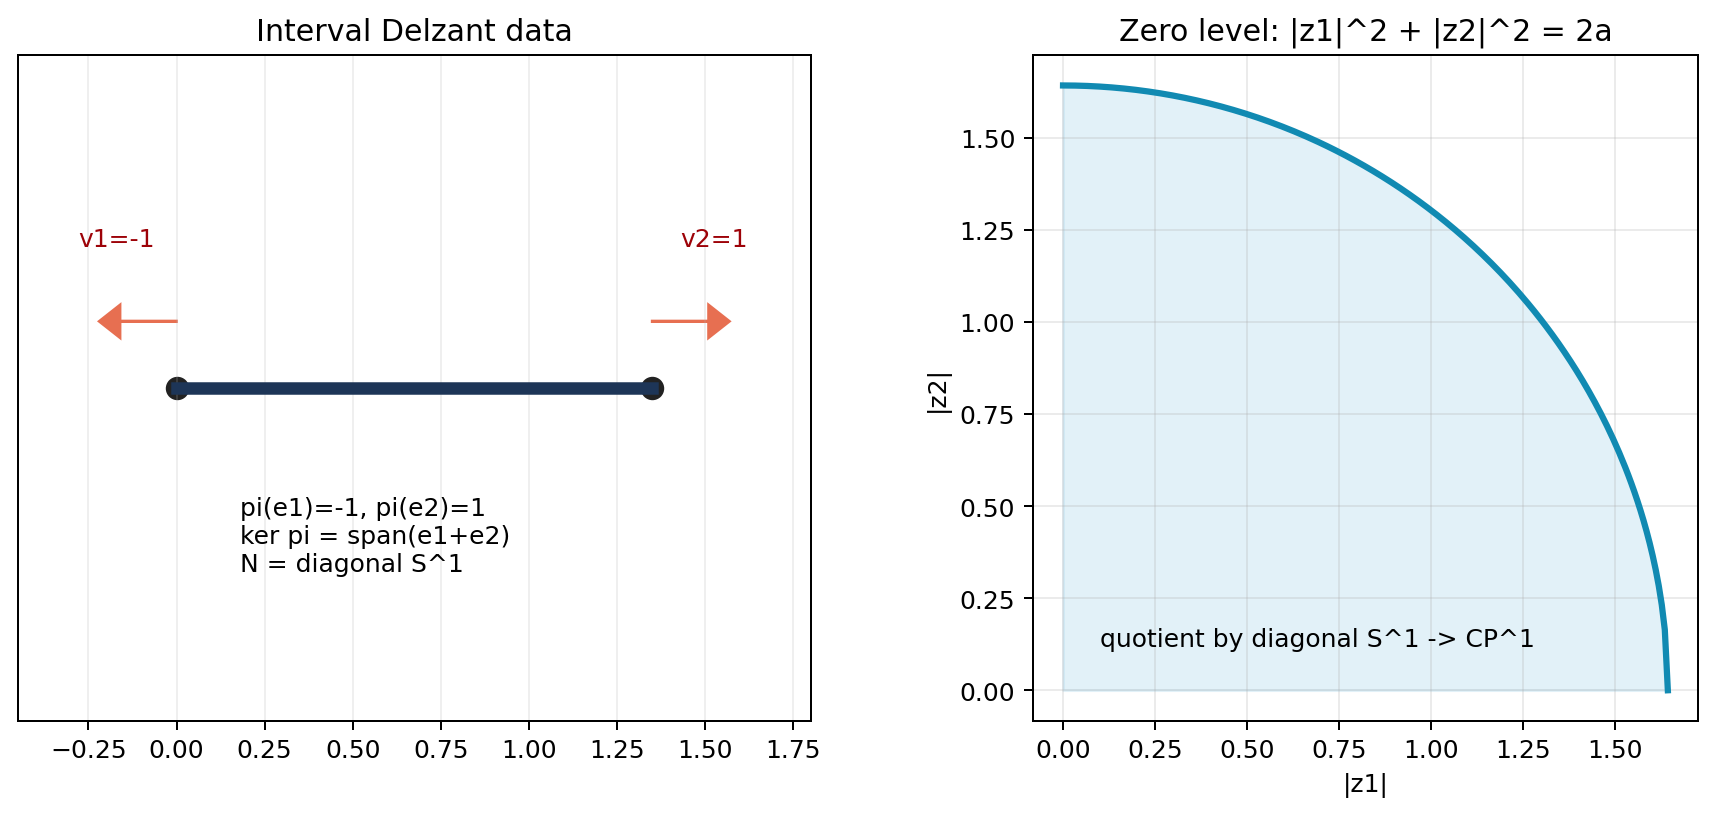

In [7]:
a = 1.35
r = np.linspace(0, math.sqrt(2 * a), 200)
r2 = np.sqrt(np.maximum(2 * a - r**2, 0))
zero_level_values = -0.5 * (r**2 + r2**2) + a
zero_level_max_residual = float(np.max(np.abs(zero_level_values)))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
axes[0].plot([0, a], [0, 0], color="#1d3557", lw=5)
axes[0].scatter([0, a], [0, 0], color="#222222", s=70)
axes[0].arrow(0, 0.08, -0.22, 0, color="#e76f51", head_width=0.04, length_includes_head=True)
axes[0].arrow(a, 0.08, 0.22, 0, color="#e76f51", head_width=0.04, length_includes_head=True)
axes[0].text(-0.28, 0.17, "v1=-1", color="#9d0208", fontsize=10)
axes[0].text(a + 0.08, 0.17, "v2=1", color="#9d0208", fontsize=10)
axes[0].text(0.18, -0.22, "pi(e1)=-1, pi(e2)=1\nker pi = span(e1+e2)\nN = diagonal S^1", fontsize=10)
axes[0].set_title("Interval Delzant data")
axes[0].set_xlim(-0.45, a + 0.45)
axes[0].set_ylim(-0.4, 0.4)
axes[0].set_yticks([])
axes[0].grid(True, axis="x", alpha=0.2)

axes[1].plot(r, r2, color="#118ab2", lw=2.5)
axes[1].fill_between(r, 0, r2, color="#8ecae6", alpha=0.25)
axes[1].set_aspect("equal")
axes[1].set_xlabel("|z1|")
axes[1].set_ylabel("|z2|")
axes[1].set_title("Zero level: |z1|^2 + |z2|^2 = 2a")
axes[1].text(0.1, 0.12, "quotient by diagonal S^1 -> CP^1", fontsize=10)
axes[1].grid(True, alpha=0.25)

interval_path = FIGURES / "interval-polytope-cp1-reduction.png"
fig.savefig(interval_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert zero_level_max_residual < 1e-12
display_artifact(rel(interval_path))

## Final Checks

The final ledger checks that the notebook captures the lecture's information rather than merely redrawing a few polygons. It verifies Delzant smoothness for the standard simplex, detects a nonsmooth rational corner, records primitive normal and half-space data, checks the exact-sequence rank/kernel count, confirms the construction route, and validates the interval zero level that reduces to `CP^1`.

In [8]:
results = {
    "standard_simplex_adjacent_normal_determinants": standard_dets,
    "standard_simplex_smooth_defect": standard_defect,
    "bad_triangle_adjacent_normal_determinants": bad_dets,
    "bad_triangle_smooth_defect": bad_smooth_defect,
    "primitive_normal_checks": primitive_checks,
    "halfspace_active_vertices": [list(v) for v in active_vertices],
    "classification_route_has_path": nx.has_path(G, "Delzant polytope", "toric manifold with image Delta"),
    "classification_route_is_dag": nx.is_directed_acyclic_graph(G),
    "pi_rank": rank_pi,
    "kernel_dimension": kernel_dim,
    "kernel_residual": kernel_residual,
    "interval_zero_level_max_residual": zero_level_max_residual,
}
write_json(CHECKS / "delzant-classification-residuals.json", results)

final_sanity = {
    "passed": True,
    "artifacts": [
        rel(FIGURES / "delzant-polygon-normal-checks.png"),
        rel(FIGURES / "simplex-halfspace-primitive-normals.png"),
        rel(FIGURES / "delzant-classification-proof-route.png"),
        rel(FIGURES / "delzant-construction-exact-sequence.png"),
        rel(FIGURES / "interval-polytope-cp1-reduction.png"),
        rel(CHECKS / "source-span.json"),
        rel(CHECKS / "visual-storyboard.json"),
        rel(CHECKS / "delzant-classification-residuals.json"),
    ],
    "assertions": {
        "standard_simplex_is_smooth": standard_defect == 0,
        "bad_triangle_detected": bad_smooth_defect > 0,
        "all_source_normals_are_primitive": all(primitive_checks),
        "three_active_vertices": len(active_vertices) == 3,
        "classification_route_valid": nx.has_path(G, "Delzant polytope", "toric manifold with image Delta"),
        "pi_has_full_rank": rank_pi == 2,
        "kernel_dimension_is_d_minus_n": kernel_dim == 1,
        "interval_zero_level_valid": zero_level_max_residual < 1e-12,
    },
    "coverage_note": "Covers Lecture 28 sections 28.1-28.3 and the interval CP1 construction example without copied source prose.",
}
write_json(CHECKS / "final-sanity.json", final_sanity)

for relative_path in final_sanity["artifacts"]:
    artifact = BOOK_ROOT / relative_path
    assert artifact.exists(), relative_path
    assert artifact.stat().st_size > 0, relative_path

for name, ok in final_sanity["assertions"].items():
    assert ok, name

print(json.dumps(final_sanity, indent=2))

{
  "passed": true,
  "artifacts": [
    "artifacts/lecture-28/figures/delzant-polygon-normal-checks.png",
    "artifacts/lecture-28/figures/simplex-halfspace-primitive-normals.png",
    "artifacts/lecture-28/figures/delzant-classification-proof-route.png",
    "artifacts/lecture-28/figures/delzant-construction-exact-sequence.png",
    "artifacts/lecture-28/figures/interval-polytope-cp1-reduction.png",
    "artifacts/lecture-28/checks/source-span.json",
    "artifacts/lecture-28/checks/visual-storyboard.json",
    "artifacts/lecture-28/checks/delzant-classification-residuals.json"
  ],
  "assertions": {
    "standard_simplex_is_smooth": true,
    "bad_triangle_detected": true,
    "all_source_normals_are_primitive": true,
    "three_active_vertices": true,
    "classification_route_valid": true,
    "pi_has_full_rank": true,
    "kernel_dimension_is_d_minus_n": true,
    "interval_zero_level_valid": true
  },
  "coverage_note": "Covers Lecture 28 sections 28.1-28.3 and the interval CP1

## Takeaways And Exploration

The Delzant theorem says that the moment image completely classifies compact symplectic toric manifolds as Hamiltonian torus spaces. The word "Delzant" hides three tests: simple, rational, and smooth. The primitive outward normals are the algebraic bridge from a polytope to the exact sequence of tori, and the kernel subtorus is the symmetry removed by reduction. The interval example shows the construction in miniature: two facets, one kernel circle, a zero sphere in `C^2`, and quotient `CP^1`.

For a short exploration, change the slanted normal in the bad triangle from `(1,2)` to `(1,k)`. The determinant test immediately tells you which values can be smooth at the top vertex, and the construction route explains why that lattice defect matters for the resulting toric space.